# Linear Genetic Programming

Linear genetic programming (LGP) is an evolutionary programming paradigm. This paradigm represents the program as a sequence of instructions, where each sequence is either an operation

$$r_0 \leftarrow \textrm{add}\, (r_1,c_1)$$

or a control structure

$$\textbf{if}\; \textit{condition}\; \textbf{then}\; \{ \cdots\}.$$

Since the topic is complex, this tutorial has two parts:

* [Running LGP](#Running-LGP) demonstrates a use case of linear genetic programming.

* [Exploring the Backstage](#Exploring-the-Backstage) shows how pieces of the module work together &#x2013; a custom interpreter, the scope, and

## Running LGP

An LGP algorithm optimises linear genetic programs. Each program has instructions that operate on registers. These registers can be one of the following:

* Variable registers (or simply registers) can be assigned to. These registers initialise to inputs of the program. Outputs of the program are taken from these registers when the program halts.

* Constant registers (or simply constants) are fixed.

Like any machine learning paradigm, LGP learns from fitness cases. Each fitness case has the following form

```
(inputs: Sequence[Number], output: Number).
```

Let's generate some!

In [23]:
from evokit.evolvables.primitives import add, sub, mul, div, sin, cos

import random
ASSURANCE_CASE_COUNT = 20
REGISTER_COUNT = 2
CONSTANT_COUNT = 4
registerses = [[random.random() for _ in range(REGISTER_COUNT)] for _ in range(ASSURANCE_CASE_COUNT)]
constantses = [(0., 1., 2., -1.) for _ in range(ASSURANCE_CASE_COUNT)]

def demo_function(registers: list[float], constants: tuple[float,
                                                           float,
                                                           float,
                                                           float]) -> list[float]:
    r = registers.copy()
    c = constants

    r[0] = r[0] * c[1]
    r[0] = r[0] + c[1]
    if r[1] < c[0]:
        r[1] = sin(r[0])
        r[1] = r[1] * 5
    return r

inputs = list(zip(registerses, constantses))

outputs = [[demo_function(registers, constants)[0]]
           for registers, constants in inputs]

In [24]:
fitness_cases = list(zip(inputs,
                         outputs))

Let MSE be the error function, and run the algorithm.

In [25]:
from evokit.evolvables.lgp import LGPEvaluator, LinearGeneticProgram, Crossover, LGPFactory

from evokit.core import Population
from evokit.evolvables.algorithms import SimpleLinearAlgorithm

from evokit.evolvables.lgp import LGPEvaluator, Crossover

from evokit.evolvables.selectors import TruncationSelector
from typing import Sequence
def maybe_mse(xs: Sequence[float],
              ys: Sequence[float]):
    return -sum((abs(x - y)**2
                for x, y in zip(xs, ys)))

IND_SIZE = 2

POP_SIZE = 40

factora = LGPFactory(
    primitives=[add, sub, mul, div, sin, cos],
    register_count=REGISTER_COUNT,
    constant_count=CONSTANT_COUNT,
)

OUTPUT_INDEX = 1

pop: Population[LinearGeneticProgram] = Population(
        [factora.build_fully_effective(segment_length=IND_SIZE,
                                       output_indices={0})
         for _ in range(POP_SIZE)]
)

evaluator = LGPEvaluator(fitness_cases=list(fitness_cases),
             fitness_function=maybe_mse,
             optimise_mode="mask",
             output_indices={1},)

variator = Crossover(k=4,
                     allow_repeat=False,
                     even=False)

selector = TruncationSelector(budget=POP_SIZE)


algo = SimpleLinearAlgorithm(population=pop,
                             variator=variator,
                             evaluator=evaluator,
                             selector=selector)

In [26]:
from typing import Callable
import time
from evokit.watch.watchers import create_fitness_watcher
from evokit.watch.visual import plot


WATCHER_TIMER: Callable[[], float] = time.perf_counter

default_watcher_settings = {
    "events": "STEP_END",
    "watch_post_step":True,
    "timer": WATCHER_TIMER
}

fitness_watcher = create_fitness_watcher(**default_watcher_settings)
algo.register(fitness_watcher)

In [27]:
for _ in range(90):
    algo.step()

In [28]:
algo.population[9].genome

[r[0] <- mul(r[0], c[2])]

In [29]:
fitness_watcher[0]

WatcherRecord(event='POST_STEP', generation=0, value=(-9.947176653760536,), time=2453533.1587268)

See the result.

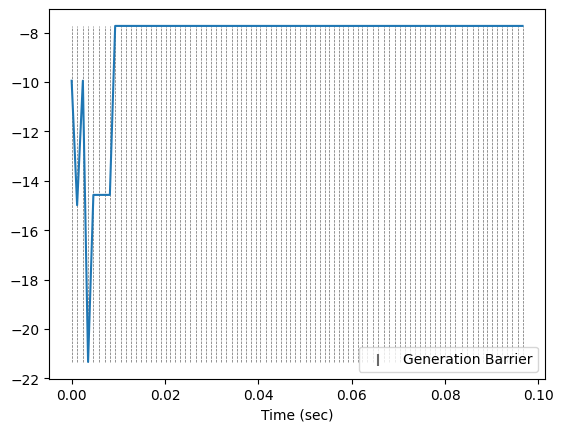

In [30]:
plot(fitness_watcher, show_generation=True, use_line=True)

## Exploring the Backstage





In [31]:
import evokit.evolvables as evolvables

In [32]:
import evokit.evolvables.lgp as lgp
from evokit.evolvables.lgp import cells

View register values of a program.

In [33]:
program = lgp.RegisterStates(registers = [3, 4, 5, 6],
                             constants = (7, 8, 9, 10, 11))
print(program)

LGP execution context here. Register states:
> r[3, 4, 5, 6], c(7, 8, 9, 10, 11)
